# 03 - DBSCAN clustering of driving windows

Same starting point as the KMeans notebook (per-window features), but here
we use DBSCAN. DBSCAN does two useful things that KMeans cannot:

- It decides the number of clusters on its own.
- It explicitly labels outliers (windows that don't fit any cluster) with
  `-1`, which is exactly what we want when looking for unusual driving.

Plan:

1. Standardize the same window features used in notebook 02.
2. Use a k-distance plot to pick a reasonable `eps`.
3. Small grid search over `(eps, min_samples)` reporting cluster count,
   noise fraction and silhouette.
4. Apply the chosen parameters, profile the clusters, and compare with the
   KMeans labels saved in notebook 02.


In [1]:
import sys, os
from pathlib import Path

# Make the project root importable so that `import src` works no matter where
# Jupyter was launched from.
HERE = Path(os.getcwd()).resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root:", ROOT)


project root: C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

from src.io import load_cleaned
from src.features import build_window_feature_table, feature_columns, BEHAVIOR_SENSORS

sns.set_theme(style="whitegrid")
RNG = 42


## 1. Build window features (same as notebook 02)

In [3]:
df = load_cleaned()
windows = build_window_feature_table(df, window_size=5, sensors=BEHAVIOR_SENSORS)
feat_cols = feature_columns(windows)
X = windows[feat_cols].fillna(0.0).to_numpy()
X_scaled = StandardScaler().fit_transform(X)
print("windows:", X_scaled.shape)


C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model\src\features.py:57: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  vskew = float(skew(values, bias=False))


windows: (4997, 60)


## 2. k-distance plot to pick `eps`

For DBSCAN, a good heuristic for `eps` is the "knee" in the sorted
k-distance plot, where `k = min_samples`. We sweep a couple of
`min_samples` values to see how robust the knee is.


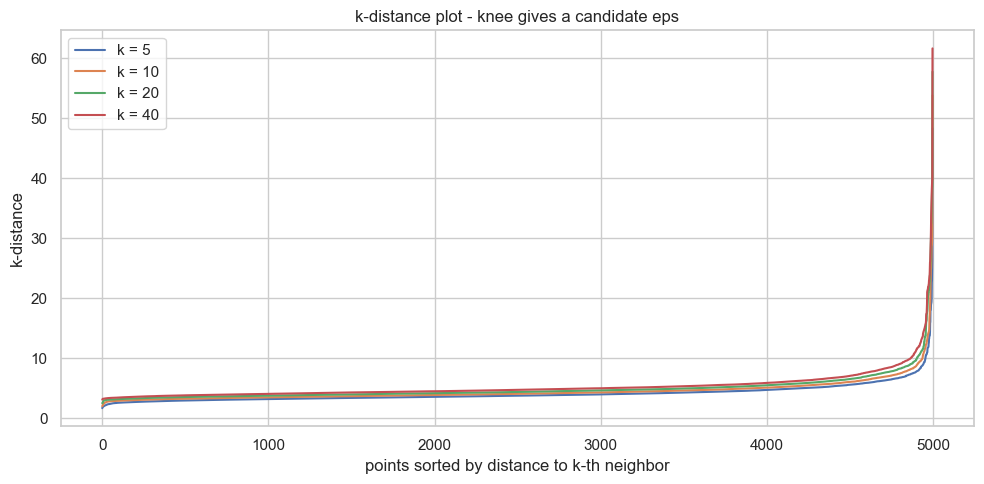

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for k in [5, 10, 20, 40]:
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    dists, _ = nn.kneighbors(X_scaled)
    kdist = np.sort(dists[:, -1])
    ax.plot(kdist, label=f"k = {k}")
ax.set_xlabel("points sorted by distance to k-th neighbor")
ax.set_ylabel("k-distance")
ax.set_title("k-distance plot - knee gives a candidate eps")
ax.legend(); plt.tight_layout(); plt.show()


## 3. Grid search

In [5]:
eps_values = np.round(np.linspace(2.0, 6.0, 9), 2)
min_samples_values = [10, 20, 40]

rows = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=float(eps), min_samples=ms, n_jobs=-1).fit(X_scaled)
        labels = db.labels_
        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = 100 * (labels == -1).mean()
        if n_clusters >= 2 and mask.sum() > 10:
            sil = silhouette_score(X_scaled[mask], labels[mask], sample_size=3000, random_state=RNG)
        else:
            sil = np.nan
        rows.append({"eps": float(eps), "min_samples": ms,
                     "n_clusters": int(n_clusters),
                     "noise_pct": round(noise_pct, 2),
                     "silhouette": round(sil, 3) if sil == sil else np.nan})

grid = pd.DataFrame(rows)
grid


,eps,min_samples,n_clusters,noise_pct,silhouette
0,2.0,10,1,99.78,NaN
1,2.0,20,0,100.00,NaN
2,2.0,40,0,100.00,NaN
3,2.5,10,1,99.20,NaN
4,2.5,20,1,99.60,NaN
5,2.5,40,0,100.00,NaN
6,3.0,10,10,85.49,0.011
7,3.0,20,4,95.82,0.175
8,3.0,40,0,100.00,NaN
9,3.5,10,5,55.55,0.094


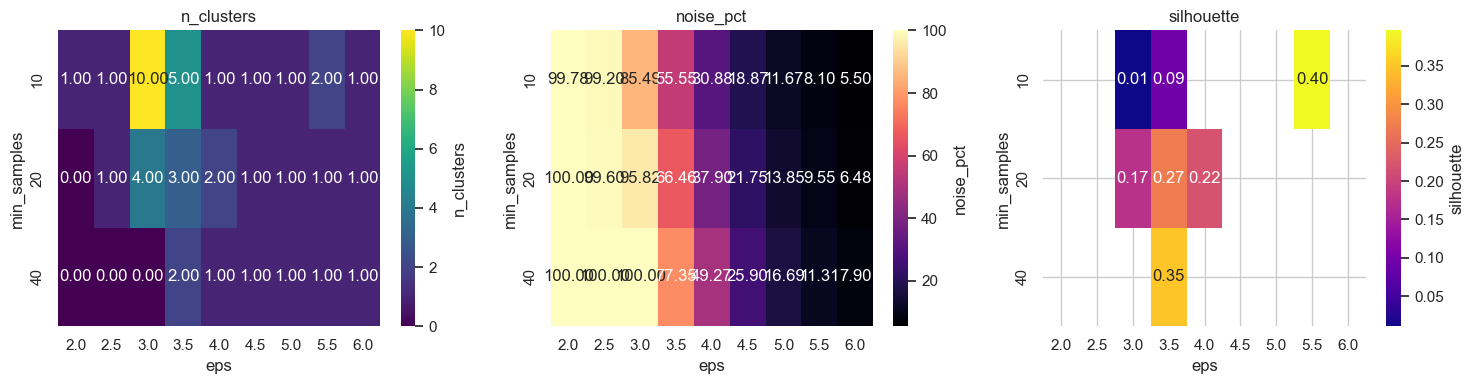

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, cmap in zip(
    axes,
    ["n_clusters", "noise_pct", "silhouette"],
    ["viridis", "magma", "plasma"],
):
    pivot = grid.pivot(index="min_samples", columns="eps", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax,
                cbar_kws={"label": metric})
    ax.set_title(metric)
plt.tight_layout(); plt.show()


### Pick `(eps, min_samples)`

We pick the configuration with the highest silhouette score among those
that produce a *reasonable* number of clusters (2-10) and a moderate
noise fraction (between 2% and 25%). If nothing matches, we fall back
to the global maximum.


In [7]:
candidates = grid[(grid["n_clusters"].between(2, 10)) &
                  (grid["noise_pct"].between(2, 25)) &
                  (grid["silhouette"].notna())]
if len(candidates) == 0:
    candidates = grid.dropna(subset=["silhouette"])
best = candidates.sort_values("silhouette", ascending=False).iloc[0]
chosen_eps = float(best["eps"])
chosen_ms = int(best["min_samples"])
print("chosen eps =", chosen_eps, " min_samples =", chosen_ms)
print(best)


chosen eps = 5.5  min_samples = 10
eps             5.500
min_samples    10.000
n_clusters      2.000
noise_pct       8.100
silhouette      0.396
Name: 21, dtype: float64


## 4. Apply DBSCAN and visualize

In [8]:
dbscan = DBSCAN(eps=chosen_eps, min_samples=chosen_ms, n_jobs=-1)
windows["cluster"] = dbscan.fit_predict(X_scaled)

n_clusters = int((windows["cluster"] != -1).any() and windows["cluster"].max() + 1)
n_noise = int((windows["cluster"] == -1).sum())
print(f"clusters: {n_clusters}, noise points: {n_noise} ({100*n_noise/len(windows):.1f}%)")

windows["cluster"].value_counts().sort_index()


clusters: 2, noise points: 405 (8.1%)


cluster
-1     405
 0    4582
 1      10
Name: count, dtype: int64

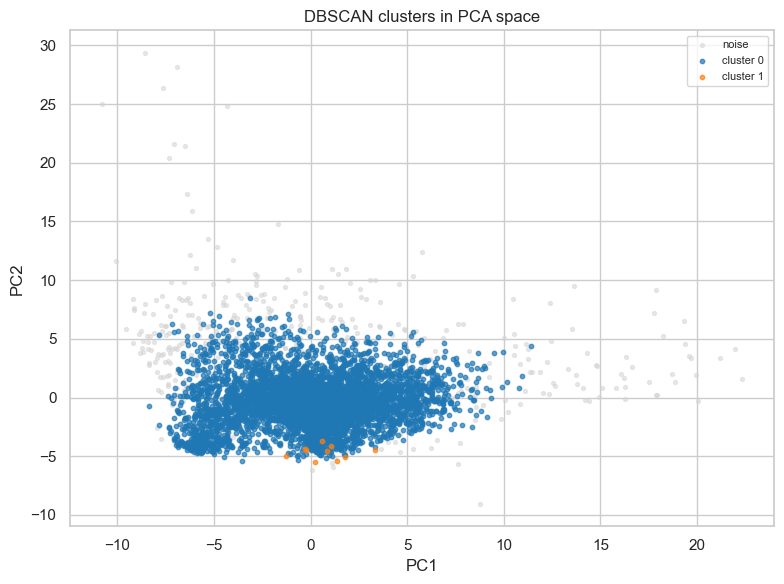

In [9]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
labels = windows["cluster"].to_numpy()
noise = labels == -1
ax.scatter(X_pca[noise, 0], X_pca[noise, 1], s=8, c="lightgrey", label="noise", alpha=0.5)
unique = sorted(set(labels) - {-1})
palette = sns.color_palette("tab10", max(len(unique), 1))
for col, c in zip(palette, unique):
    m = labels == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=10, color=col, label=f"cluster {c}", alpha=0.7)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("DBSCAN clusters in PCA space")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Profile clusters

In [10]:
profile_features = [
    "vehicle_speed__mean",
    "vehicle_speed__std",
    "acceleration_speed_longitudinal__std",
    "acceleration_speed_lateral__std",
    "master_cylinder_pressure__max",
    "steering_wheel_speed__std",
    "engine_speed__mean",
]
profile_features = [c for c in profile_features if c in windows.columns]

profile = windows.groupby("cluster")[profile_features].mean().round(2)
profile["n_windows"] = windows["cluster"].value_counts().sort_index()
profile


,vehicle_speed__mean,vehicle_speed__std,acceleration_speed_longitudinal__std,acceleration_speed_lateral__std,master_cylinder_pressure__max,steering_wheel_speed__std,engine_speed__mean,n_windows
cluster,,,,,,,,
-1,23.20,11.24,0.62,0.58,23.19,49.23,1442.92,405
0,27.08,14.68,0.44,0.25,15.65,8.72,1383.05,4582
1,33.30,3.03,0.21,0.18,1.08,3.40,1975.48,10


## 6. Compare DBSCAN with the KMeans labels from notebook 02

In [11]:
KM_PATH = ROOT / "reports" / "outputs" / "windows_kmeans.csv"
if KM_PATH.exists():
    km = pd.read_csv(KM_PATH).rename(columns={"cluster": "kmeans_cluster"})
    joined = windows.merge(km[["global_window_id", "kmeans_cluster"]], on="global_window_id", how="left")
    mask = joined["kmeans_cluster"].notna()
    ari = adjusted_rand_score(joined.loc[mask, "kmeans_cluster"], joined.loc[mask, "cluster"])
    print(f"Adjusted Rand Index (DBSCAN vs KMeans): {ari:.3f}")
    crosstab = pd.crosstab(joined["kmeans_cluster"], joined["cluster"], margins=True)
    crosstab
else:
    print("Run notebook 02 first to produce windows_kmeans.csv for comparison.")


Adjusted Rand Index (DBSCAN vs KMeans): 0.151


In [12]:
OUT = ROOT / "reports" / "outputs" / "windows_dbscan.csv"
OUT.parent.mkdir(parents=True, exist_ok=True)
windows[["driver_id", "window_id", "global_window_id", "cluster"]].to_csv(OUT, index=False)
print("saved:", OUT.relative_to(ROOT))


saved: reports\outputs\windows_dbscan.csv
